This is a textblock

In [ ]:
# Import Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Let's get our data loaded into a Pandas data fram and call df

df = pd.read_excel('/content/drive/MyDrive/GEOG341/DataAnalysisProjects/HW1_MtToms_data.xlsx')

In [ ]:
df['Decimal Days'] = df['Hour'] // 24

In [ ]:
df

,sample,Hour,m/s,Decimal Days
0,1,0.166667,1.609340,0.0
1,2,0.333333,1.162300,0.0
2,3,0.500000,1.162300,0.0
3,4,0.666667,0.849376,0.0
4,5,0.833333,1.162300,0.0
...,...,...,...,...
4459,4460,743.333333,9.030210,30.0
4460,4461,743.500000,8.761980,30.0
4461,4462,743.666667,8.136130,30.0
4462,4463,743.833333,8.091420,30.0


In [ ]:
new_df = df.groupby('Decimal Days')['m/s'].mean().reset_index()

In [ ]:
new_df

,Decimal Days,m/s
0,0.0,3.733253
1,1.0,5.746016
2,2.0,3.150700
3,3.0,5.637361
4,4.0,5.715592
5,5.0,2.224645
6,6.0,2.211295
7,7.0,5.964258
8,8.0,5.269484
9,9.0,2.650575


In [ ]:
H_hub = 100
H_sensor = 2.5
alpha = 0.14

#create new column in the dataframe with the calculated value
df['Sensor Windspeed'] = df['m/s'] * (H_hub / H_sensor)**alpha

In [ ]:
df.head(5)

,sample,Hour,m/s,Decimal Days,Sensor Windspeed
0,1,0.166667,1.609340,0.006944,2.697343
1,2,0.333333,1.162300,0.013889,1.948079
2,3,0.500000,1.162300,0.020833,1.948079
3,4,0.666667,0.849376,0.027778,1.423601
4,5,0.833333,1.162300,0.034722,1.948079


In [ ]:
# Calculate maximum and minimum wind speeds
max_wind_speed = df['m/s'].max()
min_wind_speed = df['m/s'].min()

print(f"Maximum wind speed: {max_wind_speed:.2f} m/s")
print(f"Minimum wind speed: {min_wind_speed:.2f} m/s")

Maximum wind speed: 15.65 m/s
Minimum wind speed: 0.00 m/s


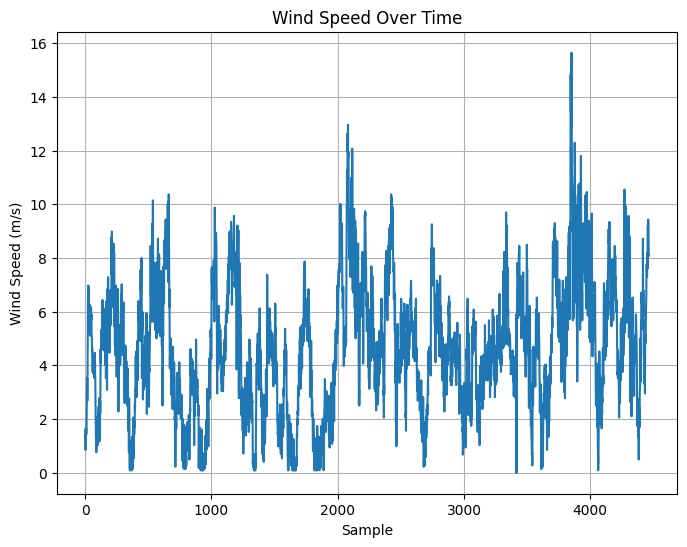

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(df['sample'], df['m/s'], linestyle='-')
plt.title('Wind Speed Over Time')
plt.xlabel('Sample')
plt.ylabel('Wind Speed (m/s)')
plt.grid(True)
plt.show()

In [ ]:
n = df['Sensor Windspeed'].count()
k = np.log2(n) + 1

In [ ]:
# Define bin edges from 0.5 to 30 with 0.5 increments
bins = np.arange(1.0, 25., 2.0)

# Compute bin midpoints
bin_midpoints = (bins[:-1] + bins[1:]) / 2

# Use pd.cut() and map bin midpoints
df['binned_value'] = pd.cut(df['Sensor Windspeed'], bins=bins, labels=bin_midpoints, right=False).astype(float)


In [ ]:
df.head(5)

,sample,Hour,m/s,Decimal Days,Sensor Windspeed,binned_value
0,1,0.166667,1.609340,0.006944,2.697343,2.0
1,2,0.333333,1.162300,0.013889,1.948079,2.0
2,3,0.500000,1.162300,0.020833,1.948079,2.0
3,4,0.666667,0.849376,0.027778,1.423601,2.0
4,5,0.833333,1.162300,0.034722,1.948079,2.0


In [ ]:
binned = df.gropuby('binned_value').sum()

NameError: name 'df' is not defined

In [ ]:
bin_counts = df.groupby('binned_value').size().to_frame(name="counts")

In [ ]:
bin_counts.head(5)

,counts
binned_value,
2.0,367
4.0,582
6.0,752
8.0,935
10.0,669


In [ ]:
bin_counts['total_time'] = bin_counts['counts'] * 10 * 60

In [ ]:
bin_counts.head(5)

,counts,total_time
binned_value,,
2.0,367,220200
4.0,582,349200
6.0,752,451200
8.0,935,561000
10.0,669,401400


In [ ]:
#calculate power in watts

rho = 1.225 # kg/m^3
A = np.pi * 126.0**2
bin_counts['Power'] = 0.5 * rho * A * bin_counts.index**3

In [ ]:
bin_counts.head(10)

,counts,total_time,Power
binned_value,,,
2.0,367,220200,2.443920e+05
4.0,582,349200,1.955136e+06
6.0,752,451200,6.598585e+06
8.0,935,561000,1.564109e+07
10.0,669,401400,3.054900e+07
12.0,446,267600,5.278868e+07
14.0,297,178200,8.382647e+07
16.0,147,88200,1.251287e+08
18.0,32,19200,1.781618e+08


In [ ]:
bin_counts['Total Power'] = (bin_counts['Power'] * bin_counts['total_time']) / 1000000 # convert Watts to Megawatts

In [ ]:
bin_counts['Power MWh'] = bin_counts['Total Power'] / 3600 # convert Megawatts to Megawatt hours

In [ ]:
bin_counts.head(5)

,counts,total_time,Power,Total Power,Power MWh
binned_value,,,,,
2.0,367,220200,2.443920e+05,5.381513e+04,14.948646
4.0,582,349200,1.955136e+06,6.827336e+05,189.648217
6.0,752,451200,6.598585e+06,2.977281e+06,827.022637
8.0,935,561000,1.564109e+07,8.774652e+06,2437.403203
10.0,669,401400,3.054900e+07,1.226237e+07,3406.213951


In [ ]:
bin_counts['Power MWh'].sum()

np.float64(19765.04268788991)

<Axes: xlabel='binned_value'>

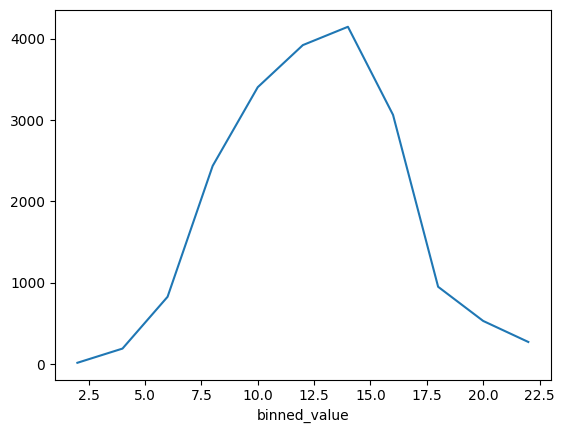

In [ ]:
bin_counts['Power MWh'].plot()

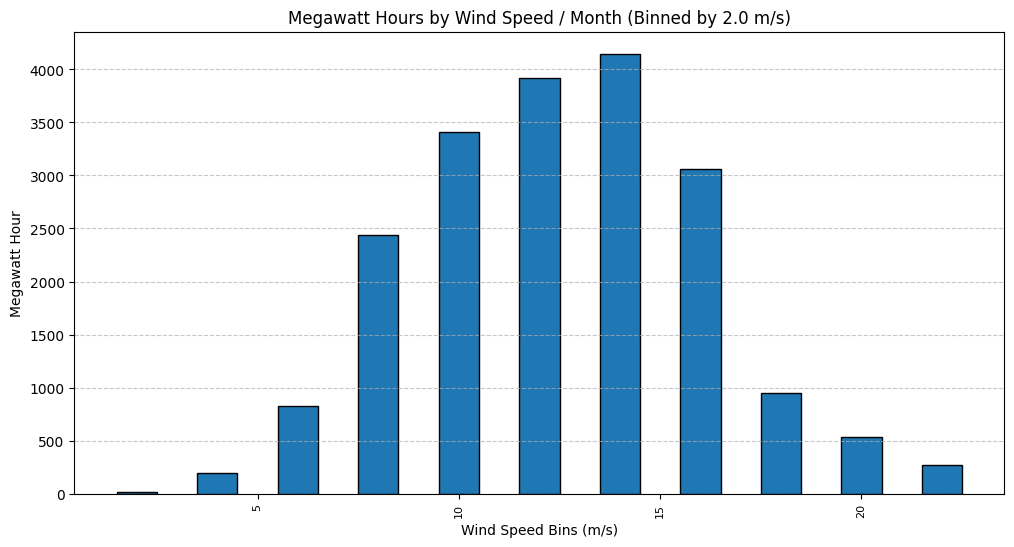

In [ ]:
import matplotlib.pyplot as plt

# Convert the bin labels to string format for better plotting
#bin['Wind Speed'] = binned_df['Wind Speed Range'].astype(str)

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(bin_counts.index, bin_counts['Power MWh'], width=1, edgecolor='black')

# Formatting
plt.xticks(rotation=90, fontsize=8)  # Rotate x-axis labels for better visibility
plt.xlabel('Wind Speed Bins (m/s)')
plt.ylabel('Megawatt Hour')
plt.title('Megawatt Hours by Wind Speed / Month (Binned by 2.0 m/s)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
bin_counts['Probability'] = bin_counts['counts'] / bin_counts['counts'].sum()

In [ ]:
bin_counts.head(5)

,counts,total_time,Power,Total Power,Power MWh,Probability
binned_value,,,,,,
2.0,367,220200,2.443920e+05,5.381513e+04,14.948646,0.086455
4.0,582,349200,1.955136e+06,6.827336e+05,189.648217,0.137102
6.0,752,451200,6.598585e+06,2.977281e+06,827.022637,0.177150
8.0,935,561000,1.564109e+07,8.774652e+06,2437.403203,0.220259
10.0,669,401400,3.054900e+07,1.226237e+07,3406.213951,0.157597


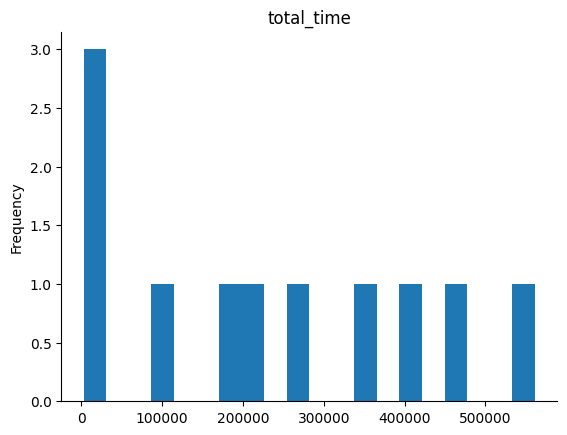

In [ ]:
# @title total_time

from matplotlib import pyplot as plt
bin_counts['total_time'].plot(kind='hist', bins=20, title='total_time')
plt.gca().spines[['top', 'right',]].set_visible(False)

<Axes: xlabel='binned_value'>

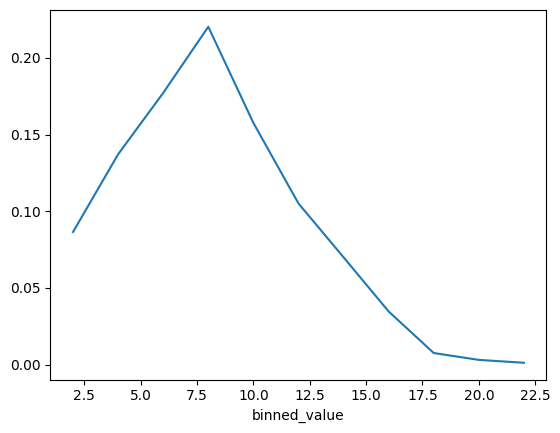

In [ ]:
bin_counts['Probability'].plot()

In [ ]:
new_df = df['w']